## Get dataset

In [2]:
import kagglehub
import os

def get_dataset(url):
    path = kagglehub.dataset_download(url)

    print("Path to dataset files:", path)

    for dirname, _, filenames in os.walk(path):
        for filename in filenames:
            print(os.path.relpath(os.path.join(dirname, filename), path))

    return path

ds_ratings_path = get_dataset("arashnic/book-recommendation-dataset")

# copy books csv
import shutil
shutil.copy(os.path.join(ds_ratings_path, "Books.csv"), ".")

Path to dataset files: /home/barto/.cache/kagglehub/datasets/arashnic/book-recommendation-dataset/versions/3
Ratings.csv
Users.csv
recsys_taxonomy2.png
classicRec.png
DeepRec.png
Books.csv


'./Books.csv'

## Dataframes

In [3]:
import numpy as np
import pandas as pd

books_df =pd.read_csv(os.path.join(ds_ratings_path, "Books.csv"),
                      dtype={"Year-Of-Publication": "string"})
users_df =pd.read_csv(os.path.join(ds_ratings_path, "Users.csv"))
ratings_df =pd.read_csv(os.path.join(ds_ratings_path, "Ratings.csv"))

ratings_df["Book-Rating"] = ratings_df["Book-Rating"].astype(float)

print("books: ", books_df.shape)
print("users: ", users_df.shape)

print("ratings all: ", ratings_df.shape)
# remove implicit 0 ratings
ratings_df = ratings_df[ratings_df["Book-Rating"] != 0]
print("ratings explicit: ", ratings_df.shape)

print(f"Rated books: {ratings_df['ISBN'].nunique()}")

print("Users: ", users_df.columns)
print()
print("Books: ", books_df.columns)
print()
print("Ratings: ", ratings_df.columns)

books:  (271360, 8)
users:  (278858, 3)
ratings all:  (1149780, 3)
ratings explicit:  (433671, 3)
Rated books: 185973
Users:  Index(['User-ID', 'Location', 'Age'], dtype='str')

Books:  Index(['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher',
       'Image-URL-S', 'Image-URL-M', 'Image-URL-L'],
      dtype='str')

Ratings:  Index(['User-ID', 'ISBN', 'Book-Rating'], dtype='str')


## Data diagnostics

In [4]:
print("Share of users who have age data: ", 1.0-users_df["Age"].isna().mean())
print("Share of users who have Location data: ", 1.0-users_df["Location"].str.strip().eq("").mean())

Share of users who have age data:  0.6028014258152895
Share of users who have Location data:  1.0


#### Ratings per book

count    185973.000000
mean          2.331903
std           6.834667
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         707.000000
Name: count, dtype: float64

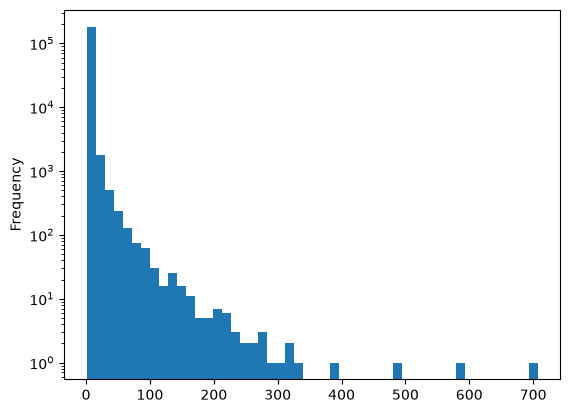

In [5]:
ratings_per_book = ratings_df["ISBN"].value_counts()
ratings_per_book.plot(kind="hist", bins=50, log=True)
ratings_per_book.describe()

#### Ratings per user

count    77805.000000
mean         5.573819
std         44.001879
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max       8524.000000
Name: count, dtype: float64

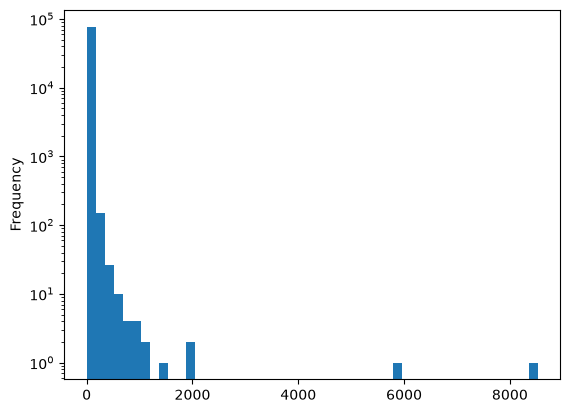

In [6]:
ratings_per_user = ratings_df["User-ID"].value_counts()
ratings_per_user.plot(kind="hist", bins=50, log=True)
ratings_per_user.describe()

#### Insight #1

Reviews per-user have higher deviation few super users with mega amounts of ratings but vast majority of users don't rank at all. For the reviews per book, most books also have no review but it is slightly more balanced. The base task also only gives one favourite book -> with a single book as favourite, and most users having no reviews finding similar users is difficult. The super users can actually benefit the item-item relations. **Item-based > User based.** I assume here I won't be using user age and location data as I don't think it can provide interesting recommandations (very surface level, generic).

In [7]:
print(f"Books count before: {ratings_df['ISBN'].nunique()}")
print(f"Users count before: {ratings_df['User-ID'].nunique()}")

# filter out books and users with few ratings
MIN_RATINGS_USER = 3
MIN_RATINGS_BOOK = 1
book_counts = ratings_df["ISBN"].value_counts()
user_counts = ratings_df["User-ID"].value_counts()


df = ratings_df.copy()
i = 0
while True:
    i += 1
    old_size = len(df)

    user_counts = df["User-ID"].value_counts()
    df = df[df["User-ID"].isin(user_counts[user_counts >= MIN_RATINGS_USER].index)]

    book_counts = df["ISBN"].value_counts()
    df = df[df["ISBN"].isin(book_counts[book_counts >= MIN_RATINGS_BOOK].index)]

    if len(df) == old_size:
        break

print(f"Iterations: {i}")

df_ratings_filtered = df.copy()

print(f"Books remaining: {df_ratings_filtered['ISBN'].nunique()}")
print(f"Users remaining: {df_ratings_filtered['User-ID'].nunique()}")

Books count before: 185973
Users count before: 77805
Iterations: 2
Books remaining: 167677
Users remaining: 22568


#### Insight #2

For item-item relations to work I need books to have ideally ratings from many users, and also users to give ratings to many books. The ladder needs to be atlest 2 to establish a relation. Since the data is so sparse I will only limit to at least 1 rating per book, but users for 2 ratings. Not ideal, some recommendations will be coincidental cause 1 users who rated this book also happened to rate this one, not necessirly cause they are similar.

#### Rated books

In [8]:
counts = df_ratings_filtered["ISBN"].value_counts()
result = books_df.set_index("ISBN").reindex(counts.index)[["Book-Title", "Book-Author"]]
result["num_ratings"] = counts.values
print(result.head())


print(f"Rated books without a title: {result["Book-Title"].isna().sum()}/{result.shape[0]}")

                                                   Book-Title    Book-Author  \
ISBN                                                                           
0316666343                          The Lovely Bones: A Novel   Alice Sebold   
0385504209                                  The Da Vinci Code      Dan Brown   
0971880107                                        Wild Animus   Rich Shapero   
0312195516                The Red Tent (Bestselling Backlist)  Anita Diamant   
059035342X  Harry Potter and the Sorcerer's Stone (Harry P...  J. K. Rowling   

            num_ratings  
ISBN                     
0316666343          497  
0385504209          381  
0971880107          334  
0312195516          270  
059035342X          257  
Rated books without a title: 29105/167677


#### Insight #3

A lot of rated books don't have a title in the our books database. We will add another dataset about books, to hopefully add missing books and also to add more data for content-based recommandation system.

In [9]:
# download dataset
ds_books_path = get_dataset("abhijitdalal26/books-dataset-with-description-85k-books")

Path to dataset files: /home/barto/.cache/kagglehub/datasets/abhijitdalal26/books-dataset-with-description-85k-books/versions/1
books_dataset.csv


In [10]:
df_books_info =pd.read_csv(os.path.join(ds_books_path, "books_dataset.csv"))
print(df_books_info.shape)
print(df_books_info.columns)

print(books_df.shape)
print(books_df.columns)

# remove unconvertable to isbn10
df_books_info = df_books_info[
    df_books_info["isbn13"].astype(str).str.startswith("978")
]
print(df_books_info.shape)

# conver to isbn10
from isbnlib import to_isbn10
df_books_info = df_books_info.rename(columns={"isbn13": "ISBN"})
df_books_info["ISBN"] = df_books_info["ISBN"].apply(to_isbn10)

# count common books
common = df_books_info["ISBN"].isin(books_df["ISBN"])
print("Common books: ", common.sum())

# rename columns and unify
df_books_combined = books_df.copy()
df_books_combined = df_books_combined.rename(columns={"Book-Title": "title"})
df_books_combined = df_books_combined.rename(columns={"Book-Author": "author"})
df_books_combined = df_books_combined.rename(columns={"Publisher": "publisher"})
df_books_combined = df_books_combined.rename(columns={"Year-Of-Publication": "pub_year"})
df_books_combined = df_books_combined.rename(columns={"Publisher": "publisher"})
df_books_combined = df_books_combined.rename(columns={"Publisher": "publisher"})
df_books_combined = df_books_combined.rename(columns={"Publisher": "publisher"})

# add new books to old books 
common_cols = df_books_combined.columns.intersection(df_books_info.columns)
new_books = df_books_info[
    ~df_books_info["ISBN"].isin(df_books_combined["ISBN"])
][common_cols]

df_books_combined = pd.concat([df_books_combined, new_books], ignore_index=True)
df_books_combined = df_books_combined.drop_duplicates("ISBN")

print(df_books_combined.shape)
print(df_books_combined.columns)

# Check missing titles now
counts = df_ratings_filtered["ISBN"].value_counts()
result = df_books_combined.set_index("ISBN").reindex(counts.index)[["title", "author"]]
result["num_ratings"] = counts.values
print(f"Rated books without a title: {result["title"].isna().sum()}/{result.shape[0]}")

(85849, 13)
Index(['isbn13', 'title', 'author', 'description', 'genres', 'avg_rating',
       'ratings_count', 'publisher', 'format', 'pages', 'pub_year',
       'series_name', 'series_position'],
      dtype='str')
(271360, 8)
Index(['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher',
       'Image-URL-S', 'Image-URL-M', 'Image-URL-L'],
      dtype='str')
(85084, 13)
Common books:  15892
(340518, 8)
Index(['ISBN', 'title', 'author', 'pub_year', 'publisher', 'Image-URL-S',
       'Image-URL-M', 'Image-URL-L'],
      dtype='str')
Rated books without a title: 28522/167677


#### Insight 4

Adding new books didn't fix missing titles: 29k -> 28k. The missing book info can be fetched manually on demand...

## Collaborative filtering, item-based

In [64]:
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.metrics.pairwise import cosine_similarity

class RecomModelCF:
    def __init__(self, k, raw=False):
        self._k = k
        self._raw = raw

    def train(self, raitings_train_df):
        user_c = raitings_train_df["User-ID"].astype("category")
        book_c = raitings_train_df["ISBN"].astype("category")
        self.matrix = csr_matrix(
            (raitings_train_df["Book-Rating"], (user_c.cat.codes, book_c.cat.codes))
        )

        self.user_categories = user_c.cat.categories
        self.book_categories = book_c.cat.categories

        if self._raw:
            return
        
        self.U, self.sigma, self.Vt = svds(self.matrix, k=self._k)

    def recommend(self, isbn, n=10):
        if self._raw:
            return self._recommend_raw(isbn, n)
        
        book_vectors = self.Vt.T

        idx = self.book_categories.get_loc(isbn)

        sims = cosine_similarity(
            book_vectors[idx].reshape(1, -1),
            book_vectors
        )[0]

        top_idx = sims.argsort()[::-1][1:n+1]

        return pd.DataFrame({
            "ISBN": self.book_categories[top_idx],
            "score": sims[top_idx]
        })

    def _recommend_raw(self, isbn, n=10):
        idx = self.book_categories.get_loc(isbn)

        sims = cosine_similarity(
            self.matrix[:, idx].T,
            self.matrix.T
        )[0]

        top_idx = sims.argsort()[::-1][1:n+1]

        return pd.DataFrame({
            "ISBN": self.book_categories[top_idx],
            "score": sims[top_idx]
        })

#### Validation

The idea behind the validation process. 
- Get N users with >M 5+ ratings of books. This user likes these books.
- Then for each user hold out one book -> remove that user ranking on that book from train dataset.
- Per user: use the held out book to get recommendations on other books, the other books that user liked should be in the recommended books.
- Measure the recall rate. 

In [67]:
def validate(model, seed=42):
    MIN_LIKED_BOOKS = 20
    MAX_LIKED_BOOKS = 1000
    N_RECALL = 25
    TEST_USERS = 1000

    # get users
    user_ids = (
        df_ratings_filtered[df_ratings_filtered["Book-Rating"] >= 7]
        .groupby("User-ID")["ISBN"]
        .nunique()
    )
    user_ids = user_ids[(user_ids >= MIN_LIKED_BOOKS) & (user_ids <= MAX_LIKED_BOOKS)]
    user_ids = user_ids.sample(min(TEST_USERS, len(user_ids)), random_state=seed).index

    # get held out books per user
    liked = df_ratings_filtered[
        (df_ratings_filtered["Book-Rating"] >= 7) &
        (df_ratings_filtered["User-ID"].isin(user_ids))
    ]
    held_out = (
        liked
        .groupby("User-ID")
        .sample(n=1, random_state=seed)
    )
    non_heldout = liked.merge(
        held_out[["User-ID", "ISBN"]],
        on=["User-ID", "ISBN"],
        how="left",
        indicator=True
    )
    non_heldout = non_heldout[
        non_heldout["_merge"] == "left_only"
    ].drop(columns="_merge")

    # remove held out books from the train set
    train_df = df_ratings_filtered.merge(
        held_out[["User-ID", "ISBN"]],
        on=["User-ID", "ISBN"],
        how="left",
        indicator=True
    )
    train_df = train_df[
        train_df["_merge"] == "left_only"
    ].drop(columns="_merge")

    # train model
    model.train(train_df)

    hits = 0
    tries = 0

    for user_id, group in non_heldout.groupby("User-ID"):
        held_out_isbn = held_out.loc[
            held_out["User-ID"] == user_id, "ISBN"
        ].iloc[0]

        other_isbns = set(group["ISBN"])

        # skip if held out book is not in the model
        if held_out_isbn not in model.book_categories:
            continue

        recommended = model.recommend(
            isbn=held_out_isbn,
            n=N_RECALL
        )

        recommended_isbns = set(recommended["ISBN"])

        overlap = recommended_isbns & other_isbns

        tries += 1
        if overlap:
            hits += 1

    print(f"Hits: {hits}/{tries} [ {hits/tries} ]")

raw_model = RecomModelCF(k=0, raw=True)
print("raw model: ")
validate(raw_model, seed=99)

for k in [5, 7, 10, 12, 15, 20, 25]:
    model = RecomModelCF(k=k)
    print(f"k = {k}")
    validate(model, seed=99)

raw model: 
Hits: 78/687 [ 0.11353711790393013 ]
k = 5
Hits: 54/687 [ 0.07860262008733625 ]
k = 7
Hits: 67/687 [ 0.0975254730713246 ]
k = 10
Hits: 75/687 [ 0.1091703056768559 ]
k = 12
Hits: 83/687 [ 0.12081513828238719 ]
k = 15
Hits: 72/687 [ 0.10480349344978165 ]
k = 20
Hits: 74/687 [ 0.10771470160116449 ]
k = 25
Hits: 81/687 [ 0.11790393013100436 ]


#### Insight 5
The hit rate isn't too high, but that to be expected as it is just a proxy. It measures if the books that we know the user liked would be recommended to him. Where the real goal is to measure if the user would like the books that were recommended, which we can't measure directly. 

The SVD doesn't provide too much of the advantage. At k=12 it provides similar hit-rate, but is more memmory efficient.

In [79]:
# model
model_cf = RecomModelCF(k=12)
model_cf.train(df_ratings_filtered)

# book searcher
from rapidfuzz import process, fuzz
class BookSearcher:
    def __init__(self, df_ratings, df_books):
        rated_isbns = df_ratings["ISBN"].unique()

        self.books = df_books[
            df_books["ISBN"].isin(rated_isbns)
        ][["ISBN", "title", "author"]].dropna(
            subset=["title"]
        ).reset_index(drop=True)

    def find_by_title(self, title):
        results = process.extract(
            title,
            self.books["title"],
            scorer=fuzz.WRatio,
            limit=5
        )

        indices = [r[2] for r in results]

        return self.books.iloc[indices].assign(
            score=[r[1] for r in results]
        ).reset_index(drop=True)


In [90]:
SEARCH_TITLE = "Lord of the Rings"

bookSearcher = BookSearcher(df_ratings_filtered, df_books_combined)

results = bookSearcher.find_by_title(SEARCH_TITLE)
print(results)

         ISBN                      title            author  score
0  0618153969      The Lord of the Rings  J. R. R. Tolkien   95.0
1  0618260250      The Lord of the Rings  J. R. R. Tolkien   95.0
2  0618260293      The Lord of the Rings  J. R. R. Tolkien   95.0
3  0618260587      The Lord of the Rings  J. R. R. Tolkien   95.0
4  0739408259  Lord of the Rings Trilogy    J.R.R. Tolkien   95.0


In [95]:
SEARCH_ISBN = '0739408259'

recommendations = model.recommend(isbn=SEARCH_ISBN, n=10)

books = recommendations.merge(
    df_books_combined[["ISBN", "title", "author"]],
    on="ISBN",
    how="left"
)

books = books[["title", "author"]]
print(books)

                                               title                    author
0                   Otherland: City Of Golden Shadow              Tad Williams
1                                  The Divine Comedy                     DANTE
2                                 Valentine Pontifex         Robert Silverberg
3                                         MILLENNIUM  Felipe Fernandez-Armesto
4                                                NaN                       NaN
5  The Bantam New College German and English Dict...          John C. Traupman
6  Covenant With the Vampire: The Diaries of the ...         Jeanne Kalogridis
7                                                NaN                       NaN
8  Roget's International Thesaurus (Roget's Inter...         Robert L. Chapman
9  The Book of the Mad (The Secret Book of Parady...                Tanith Lee
